In [1]:
import wandb
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

## Functions

In [38]:
def plot_loss_vs_lr(runs_table, ylim=None, title=None, figsize=(10, 6), ax=None, main_variable="dmodel", ax_labels_font=12, tick_font=12, title_font=12, name_map=None):
    """
    For each model width in the runs table, plots a line where the y-axis is the final loss value
    and the x-axis is the learning rate (lr). Uses different markers for finished vs running runs.
    """
    color_dict = {
        1: "#1f78b4", 2: "#33a02c", 4: "#e31a1c", 8: "#ff7f00", 16: "#6a3d9a", 32: "#a65628", 64: "#000000",
        128: "#1f78b4", 256: "#33a02c", 512: "#e31a1c", 768: "#ff7f00", 1024: "#6a3d9a", 1536: "#a65628", 2048: "#000000",
    }

    # Ensure required columns are present in runs_table
    required_columns = ["id", main_variable, "learning_rate", "final_loss"]
    for col in required_columns:
        if col not in runs_table.columns:
            print(f"Warning: Column '{col}' is missing from runs_table.")
            runs_table[col] = None

    # Get final loss values for each run
    final_loss_df = get_final_loss_values(runs_table, main_variable)

    # Remove entries with missing final loss
    final_loss_df = final_loss_df[final_loss_df["final_loss"].notnull()]
    
    if final_loss_df.empty:
        print("No data to plot after filtering out null final_loss.")
        return

    # Add completion status
    completion_map = {}
    for _, run_row in runs_table.iterrows():
        run_id = run_row["id"]
        state = run_row.get("state", "unknown")
        completion_map[run_id] = "complete" if state == "finished" else "running"
    
    final_loss_df["status"] = final_loss_df["run_id"].map(completion_map)

    final_loss_df.to_csv('final_loss_df.csv')

    # Plotting
    if ax is None:
        plt.figure(figsize=figsize)
        plot_ax = plt
    else:
        plot_ax = ax

    # Filter out None values from grid_variable before sorting
    unique_vars = [v for v in final_loss_df["grid_variable"].unique() if v is not None]
    model_widths = sorted(unique_vars)
    # model_widths = [mw for mw in model_widths if mw != "pk_mlm"]
    
    for model_width in model_widths:
        df_subset = final_loss_df[final_loss_df["grid_variable"] == model_width]
        
        # Separate finished and running runs
        # finished_runs = df_subset
        finished_runs = df_subset[df_subset["status"] == "complete"]
        running_runs = df_subset[df_subset["status"] != "complete"]
        
        color = color_dict.get(model_width, None)
        
        variable_label = "Model width:" if main_variable == "dmodel" else f"{main_variable}:"
        if name_map is not None:
            label = f"{name_map.get(model_width, model_width)}"
        else:
            label = f"{variable_label} {model_width}"
        
        # Plot finished runs with 'o' marker
        if not finished_runs.empty:
            finished_sorted = finished_runs.sort_values("lr")
            means_finished = finished_sorted.groupby("lr")["final_loss"].mean()
            lrs_finished = means_finished.index.to_numpy()
            losses_finished = means_finished.values
            
            plot_ax.plot(lrs_finished, losses_finished, marker="o", color=color, 
                        label=label, linestyle='-')
        
        # Plot running runs with square marker
        if not running_runs.empty:
            running_sorted = running_runs.sort_values("lr")
            means_running = running_sorted.groupby("lr")["final_loss"].mean()
            lrs_running = means_running.index.to_numpy()
            losses_running = means_running.values
            
            plot_ax.plot(lrs_running, losses_running, marker="s", color=color,
                        label=label, linestyle='--', markersize=6)

    if ax is None:
        plt.legend()
        plt.tick_params(axis='both', labelsize=tick_font)
        plt.xlabel("Learning Rate", fontsize=ax_labels_font)
        plt.ylabel("Final Loss Value", fontsize=ax_labels_font)
        if title is None:
            title = "Final Loss vs Learning Rate for Different Model Widths"
        plt.title(title, fontsize=title_font)
        plt.grid(True)
        plt.xscale("log")
        if ylim is not None:
            plt.ylim(ylim)
        plt.show()
    else:
        ax.legend()
        ax.set_xlabel("Learning Rate", fontsize=ax_labels_font)
        ax.set_ylabel("Final Loss Value", fontsize=ax_labels_font)
        ax.tick_params(axis='both', labelsize=tick_font)
        ax.set_xscale("log")
        if title is None:
            title = "Final Loss vs Learning Rate"
        ax.set_title(title, fontsize=title_font)
        ax.grid(True)
        if ylim is not None:
            ax.set_ylim(ylim)


def get_final_loss_values(runs_table, main_variable="dmodel"):
    final_losses = []
    for _, run_row in runs_table.iterrows():
        run_id = run_row["id"]
        model_width = run_row.get(main_variable)
        lr = run_row.get("learning_rate")
        loss = run_row.get("final_loss")

        final_losses.append(
            {"run_id": run_id, "grid_variable": model_width, "lr": lr, "final_loss": loss}
        )

    return pd.DataFrame(final_losses)

## Weights and Biases

In [31]:
def get_wandb_table(project, tags, negative_tags=None, columns=None, print_columns=False):
    api = wandb.Api()
    filters = {"tags": {"$all": tags}}
    runs = api.runs(project, filters=filters)
    
    data = []
    sample_run = None
    for run in runs:
        if sample_run is None:
            sample_run = run
        if negative_tags and any(tag in run.tags for tag in negative_tags):
            continue
            
        # Extract basic info with aggressive fallbacks
        lr = (run.config.get("trainer", {}).get("learning_rate") or 
              run.config.get("job_config/trainer/learning_rate") or 
              run.config.get("learning_rate") or
              run.summary.get("steps/train/lr") or
              run.summary.get("learning_rate"))
        lr = 10 * lr
              
        dmodel = (run.config.get("common", {}).get("dmodel") or 
                  run.config.get("job_config/common/dmodel") or 
                  run.config.get("dmodel") or
                  run.summary.get("dmodel") or
                  run.summary.get("common/dmodel"))
        
        # Try to infer dmodel from run name if it follows a pattern like 'dmodel=128'
        if dmodel is None:
            import re
            match = re.search(r"dmodel=(\d+)", run.name)
            if match:
                dmodel = int(match.group(1))

        n_steps = (run.config.get("trainer", {}).get("n_steps") or 
                   run.config.get("job_config/trainer/n_steps") or 
                   run.config.get("n_steps") or
                   run.summary.get("n_steps"))
                   
        step = run.summary.get("step") or run.summary.get("_step")
        
        final_loss = (run.summary.get("steps/eval/loss") or 
                      run.summary.get("steps/train/loss") or
                      run.summary.get("loss"))

        row = {
            "id": run.id,
            "name": run.name,
            "tags": run.tags,
            "state": run.state,
            "learning_rate": lr,
            "dmodel": dmodel,
            "n_steps": n_steps,
            "step": step,
            "final_loss": final_loss
        }
        
        if columns:
            for col in columns:
                val = run.config.get(col)
                if val is None: val = run.summary.get(col)
                row[col] = val
                    
        data.append(row)
        
    df = pd.DataFrame(data)
    print(f"Table downloaded\nShape: {df.shape}")

    if print_columns and sample_run is not None:
        print("\n=== Available keys in first run config ===")
        for k in sorted(sample_run.config.keys()):
            print(f"  {k}")
        print("\n=== Available keys in first run summary ===")
        for k in sorted(sample_run.summary.keys()):
            print(f"  {k}")
        print("========================\n")

    return df


## Plot

Table downloaded
Shape: (18, 9)

=== Available keys in first run config ===

=== Available keys in first run summary ===
  _runtime
  _step
  _timestamp
  _wandb
  step
  steps/100/time
  steps/100/train/loss
  steps/block[0]/residual_attention/residual_norms/mean
  steps/block[0]/residual_attention/residual_norms/std
  steps/block[0]/residual_attention/update_norms/mean
  steps/block[0]/residual_attention/update_norms/std
  steps/block[0]/residual_attention/update_to_residual_ratio/mean
  steps/block[0]/residual_attention/update_to_residual_ratio/std
  steps/block[0]/residual_feedforward/residual_norms/mean
  steps/block[0]/residual_feedforward/residual_norms/std
  steps/block[0]/residual_feedforward/update_norms/mean
  steps/block[0]/residual_feedforward/update_norms/std
  steps/block[0]/residual_feedforward/update_to_residual_ratio/mean
  steps/block[0]/residual_feedforward/update_to_residual_ratio/std
  steps/block[10]/residual_attention/residual_norms/mean
  steps/block[10]/residu

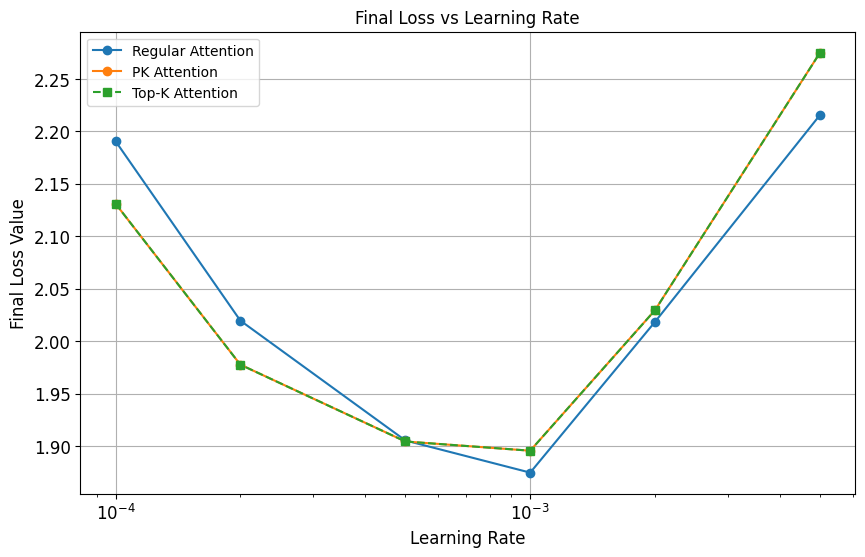

In [32]:
plots_folder = 'jm/plots'
os.makedirs(plots_folder, exist_ok=True)

project_path = "ideas_cv/tml-bgw"  # Update with your entity/project
tags1 = ["2026.02.04-grid"]
tags2 = ["2026.02.16-grid"]
negative_tags = ["fail", "pkm"]

df1 = get_wandb_table(project_path, tags1, negative_tags=negative_tags, print_columns=True)
df2 = get_wandb_table(project_path, tags2, negative_tags=negative_tags, print_columns=True)

df = pd.concat([df1, df2], ignore_index=True)
df = df1

if not df.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    plot_loss_vs_lr(df, title="Final Loss vs Learning Rate", ax=ax, main_variable="name",  name_map={"baseline": "Regular Attention", "pk_mlm": "PK Attention", "top_k_attention": "Top-K Attention"})
    plt.show()
else:
    print("No runs found with the specified tags.")

Table downloaded
Shape: (12, 9)

=== Available keys in first run config ===
  _run_
  checkpoint_config
  cluster_switch
  common
  evaluator
  infrastructure
  model
  overrides
  trainer

=== Available keys in first run summary ===
  _runtime
  _step
  _timestamp
  _wandb
  exp_lr
  full_save_checkpoints_path
  learning_rate
  step
  steps/100/time
  steps/100/train/loss
  steps/block[0]/residual_attention/residual_norms/mean
  steps/block[0]/residual_attention/residual_norms/std
  steps/block[0]/residual_attention/update_norms/mean
  steps/block[0]/residual_attention/update_norms/std
  steps/block[0]/residual_attention/update_to_residual_ratio/mean
  steps/block[0]/residual_attention/update_to_residual_ratio/std
  steps/block[0]/residual_feedforward/residual_norms/mean
  steps/block[0]/residual_feedforward/residual_norms/std
  steps/block[0]/residual_feedforward/update_norms/mean
  steps/block[0]/residual_feedforward/update_norms/std
  steps/block[0]/residual_feedforward/update_to_r

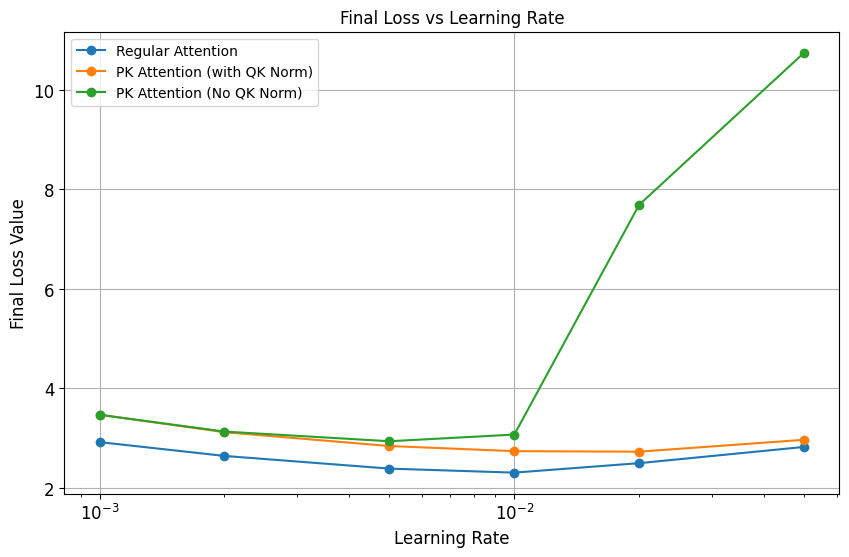

In [51]:
plots_folder = 'jm/plots'
os.makedirs(plots_folder, exist_ok=True)

project_path = "ideas_cv/tml-bgw"  # Update with your entity/project
tags1 = ["2026.04.19"]
# tags2 = ["warmup10_as_in_pk"]
tags2 = ["2026.04.20", "warmup_steps=1500", "warmup10_as_in_pk"]
tags3 = ["2026.04.19", "baseline"]
negative_tags = ["fail", "pkm"]

df1 = get_wandb_table(project_path, tags1, negative_tags=negative_tags + ["baseline"], print_columns=True)
df2 = get_wandb_table(project_path, tags2, negative_tags=negative_tags, print_columns=True)
df3 = get_wandb_table(project_path, tags3, negative_tags=negative_tags, print_columns=True)
df3 = df3[(df3["name"] == "baseline_lr_grid") & (df3["learning_rate"].isin([0.050, 0.001]))]
df = pd.concat([df1, df2, df3], ignore_index=True)
# df = df1

if not df.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    plot_loss_vs_lr(df, title="Final Loss vs Learning Rate", ax=ax, main_variable="name", name_map={"baseline_lr_grid": "Regular Attention", "pk_mlm_bring_back_rope_lr_grid": "PK Attention (with QK Norm)", "pk_mlm_bring_back_rope_no_qknorm_lr_grid": "PK Attention (No QK Norm)"})
    plt.show()
else:
    print("No runs found with the specified tags.")

Table downloaded
Shape: (28, 9)

=== Available keys in first run config ===
  _run_
  checkpoint_config
  cluster_switch
  common
  evaluator
  infrastructure
  model
  overrides
  trainer

=== Available keys in first run summary ===
  _runtime
  _step
  _timestamp
  _wandb
  exp_lr
  full_save_checkpoints_path
  learning_rate
  step
  steps/100/time
  steps/100/train/loss
  steps/block[0]/residual_attention/residual_norms/mean
  steps/block[0]/residual_attention/residual_norms/std
  steps/block[0]/residual_attention/update_norms/mean
  steps/block[0]/residual_attention/update_norms/std
  steps/block[0]/residual_attention/update_to_residual_ratio/mean
  steps/block[0]/residual_attention/update_to_residual_ratio/std
  steps/block[0]/residual_feedforward/residual_norms/mean
  steps/block[0]/residual_feedforward/residual_norms/std
  steps/block[0]/residual_feedforward/update_norms/mean
  steps/block[0]/residual_feedforward/update_norms/std
  steps/block[0]/residual_feedforward/update_to_r

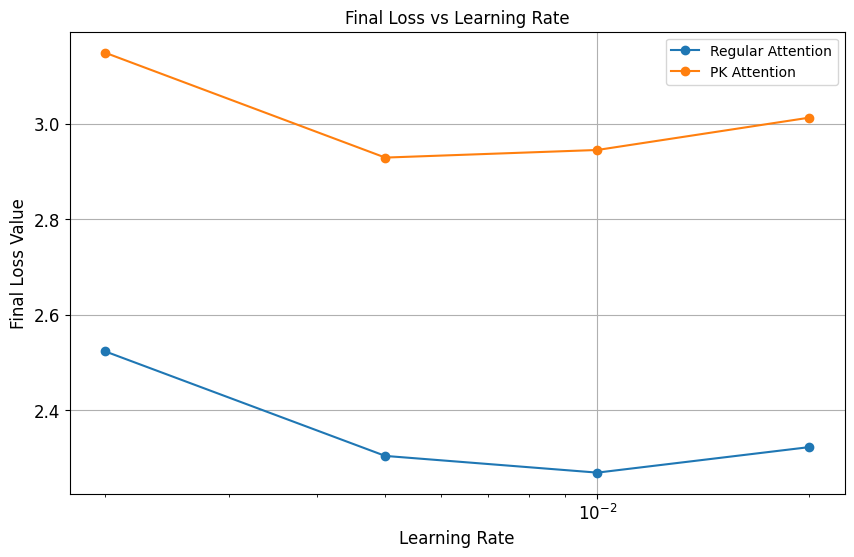

In [56]:
plots_folder = 'jm/plots'
os.makedirs(plots_folder, exist_ok=True)

project_path = "ideas_cv/tml-bgw"  # Update with your entity/project
tags1 = ["2026.04.23"]
tags2 = []
negative_tags = ["fail", "pkm"]

df1 = get_wandb_table(project_path, tags1, negative_tags=negative_tags, print_columns=True)
df1 = df1[df1["name"].isin(["baseline_lr_grid", "pk_attn_lr_grid"])]
# df2 = get_wandb_table(project_path, tags2, negative_tags=negative_tags, print_columns=True)
# df = pd.concat([df1, df2, df3], ignore_index=True)
df = df1

if not df.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    plot_loss_vs_lr(df, title="Final Loss vs Learning Rate", ax=ax, main_variable="name", name_map={"baseline_lr_grid": "Regular Attention", "pk_attn_lr_grid": "PK Attention"})
    plt.show()
else:
    print("No runs found with the specified tags.")

Table downloaded
Shape: (8, 9)

=== Available keys in first run config ===
  _run_
  checkpoint_config
  cluster_switch
  common
  evaluator
  infrastructure
  model
  overrides
  trainer

=== Available keys in first run summary ===
  _runtime
  _step
  _timestamp
  _wandb
  exp_lr
  full_save_checkpoints_path
  learning_rate
  step
  steps/100/time
  steps/100/train/loss
  steps/eval/loss
  steps/train/grad_norm
  steps/train/loss
  steps/train/lr
  steps/train/processed_tokens



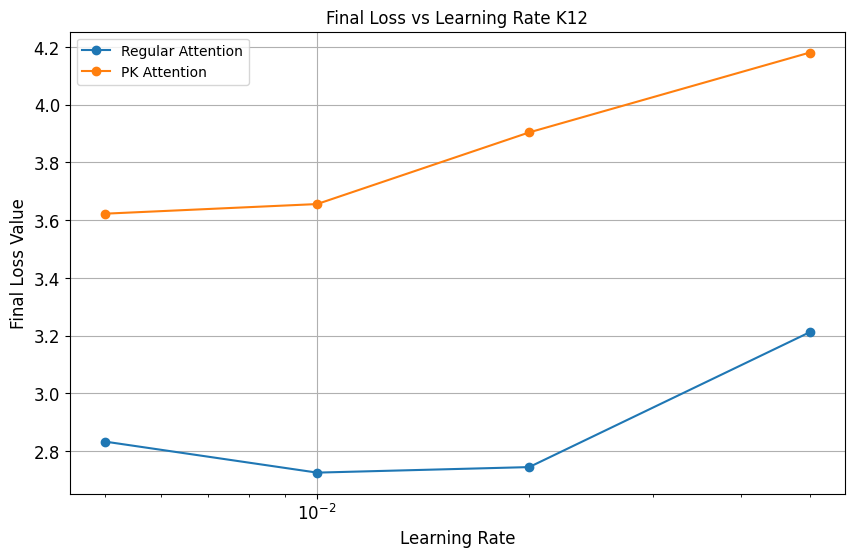

In [58]:
plots_folder = 'jm/plots'
os.makedirs(plots_folder, exist_ok=True)

project_path = "ideas_cv/tml-bgw"  # Update with your entity/project
tags1 = ["2026.04.24", "dmodel=768"]
tags2 = []
negative_tags = ["fail", "pkm"]

df1 = get_wandb_table(project_path, tags1, negative_tags=negative_tags, print_columns=True)
# df1 = df1[df1["name"].isin(["baseline_lr_grid", "pk_attn_lr_grid"])]
# df2 = get_wandb_table(project_path, tags2, negative_tags=negative_tags, print_columns=True)
# df = pd.concat([df1, df2, df3], ignore_index=True)
df = df1

if not df.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    plot_loss_vs_lr(df, title="Final Loss vs Learning Rate K12", ax=ax, main_variable="name", name_map={"baseline_lr_grid_k12": "Regular Attention", "pk_attn_lr_grid_k12": "PK Attention"})
    plt.show()
else:
    print("No runs found with the specified tags.")

Table downloaded
Shape: (8, 9)

=== Available keys in first run config ===
  _run_
  checkpoint_config
  cluster_switch
  common
  evaluator
  infrastructure
  model
  overrides
  trainer

=== Available keys in first run summary ===
  _runtime
  _step
  _timestamp
  _wandb
  exp_lr
  full_save_checkpoints_path
  learning_rate
  step
  steps/100/time
  steps/100/train/loss
  steps/block[0]/residual_attention/residual_norms/mean
  steps/block[0]/residual_attention/residual_norms/std
  steps/block[0]/residual_attention/update_norms/mean
  steps/block[0]/residual_attention/update_norms/std
  steps/block[0]/residual_attention/update_to_residual_ratio/mean
  steps/block[0]/residual_attention/update_to_residual_ratio/std
  steps/block[0]/residual_feedforward/residual_norms/mean
  steps/block[0]/residual_feedforward/residual_norms/std
  steps/block[0]/residual_feedforward/update_norms/mean
  steps/block[0]/residual_feedforward/update_norms/std
  steps/block[0]/residual_feedforward/update_to_re

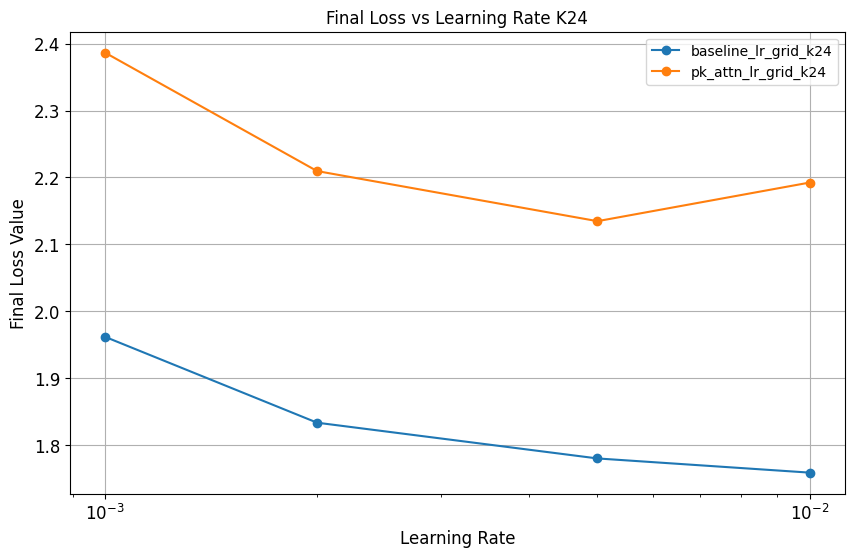

In [59]:
plots_folder = 'jm/plots'
os.makedirs(plots_folder, exist_ok=True)

project_path = "ideas_cv/tml-bgw"  # Update with your entity/project
tags1 = ["2026.04.24", "dmodel=1536"]
tags2 = []
negative_tags = ["fail", "pkm"]

df1 = get_wandb_table(project_path, tags1, negative_tags=negative_tags, print_columns=True)
# df1 = df1[df1["name"].isin(["baseline_lr_grid", "pk_attn_lr_grid"])]
# df2 = get_wandb_table(project_path, tags2, negative_tags=negative_tags, print_columns=True)
# df = pd.concat([df1, df2, df3], ignore_index=True)
df = df1

if not df.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    plot_loss_vs_lr(df, title="Final Loss vs Learning Rate K24", ax=ax, main_variable="name", name_map={"baseline_lr_grid_k12": "Regular Attention", "pk_attn_lr_grid_k12": "PK Attention"})
    plt.show()
else:
    print("No runs found with the specified tags.")

In [50]:
df1 = get_wandb_table(project_path, tags1, negative_tags=negative_tags, print_columns=True)
df1[(df1["name"] == "baseline_lr_grid") & (df1["learning_rate"].isin([0.050, 0.001]))]

Table downloaded
Shape: (18, 9)

=== Available keys in first run config ===
  _run_
  checkpoint_config
  cluster_switch
  common
  evaluator
  infrastructure
  model
  overrides
  trainer

=== Available keys in first run summary ===
  _runtime
  _step
  _timestamp
  _wandb
  exp_lr
  full_save_checkpoints_path
  learning_rate
  step
  steps/100/time
  steps/100/train/loss
  steps/block[0]/residual_attention/residual_norms/mean
  steps/block[0]/residual_attention/residual_norms/std
  steps/block[0]/residual_attention/update_norms/mean
  steps/block[0]/residual_attention/update_norms/std
  steps/block[0]/residual_attention/update_to_residual_ratio/mean
  steps/block[0]/residual_attention/update_to_residual_ratio/std
  steps/block[0]/residual_feedforward/residual_norms/mean
  steps/block[0]/residual_feedforward/residual_norms/std
  steps/block[0]/residual_feedforward/update_norms/mean
  steps/block[0]/residual_feedforward/update_norms/std
  steps/block[0]/residual_feedforward/update_to_r

,id,name,tags,state,learning_rate,dmodel,n_steps,step,final_loss
16,bbwinhmb,baseline_lr_grid,"[2026.04.19, baseline, dmodel=1024, learning_r...",finished,0.001,1024,15000,14999,2.918750
17,wt5i80ww,baseline_lr_grid,"[2026.04.19, baseline, dmodel=1024, learning_r...",finished,0.050,1024,15000,14999,2.822266


In [46]:
df3[df3["learning_rate"].isin([0.050, 0.001])]

,id,name,tags,state,learning_rate,dmodel,n_steps,step,final_loss
4,iu5rc64r,baseline_lr_grid,"[2026.04.20, baseline, dmodel=1024, find_optim...",finished,0.001,1024,15000,14999,2.964062
9,sezeud4w,baseline_lr_grid,"[2026.04.20, baseline, dmodel=1024, find_optim...",finished,0.050,1024,15000,14999,2.701172
10,sfp2z958,baseline_lr_grid,"[2026.04.20, baseline, dmodel=1024, find_optim...",finished,0.001,1024,15000,14999,2.964453
15,ir4hl24e,baseline_lr_grid,"[2026.04.20, baseline, dmodel=1024, find_optim...",finished,0.050,1024,15000,14999,2.707422
16,5797nx92,baseline_lr_grid,"[2026.04.20, baseline, dmodel=1024, find_optim...",finished,0.001,1024,15000,14999,2.921484
21,lyvmerq0,baseline_lr_grid,"[2026.04.20, baseline, dmodel=1024, find_optim...",finished,0.050,1024,15000,14999,2.755078
